In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)

def get_scaled_fontsizes(fig_width, fig_height, base_figsize=(6, 4), base_fontsizes=None):
    if base_fontsizes is None:
        base_fontsizes = {
            'label': 16,
            'title': 16,
            'legend': 14,
            'xtick': 14,
            'ytick': 14
        }
    width_scale = fig_width / base_figsize[0]
    height_scale = fig_height / base_figsize[1]
    scale = (width_scale + height_scale) / 2.0

    return {k: v * scale for k, v in base_fontsizes.items()}

def apply_figure_style(fig_width=7.2, fig_height=5):
    fonts = get_scaled_fontsizes(fig_width, fig_height)
    plt.rcParams.update({
        #'text.usetex': True,
        'font.family': 'STIXGeneral',
        'mathtext.fontset': 'cm',
        'figure.figsize': (fig_width, fig_height),
        'axes.labelsize': fonts['label'],
        'axes.titlesize': fonts['title'],
        'legend.fontsize': fonts['legend'],
        'xtick.labelsize': fonts['xtick'],
        'ytick.labelsize': fonts['ytick'],
    })

#apply_figure_style(6, 4)

/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


-- SMALL SYSTEM --
Fetched data for small system. Generating plot...


/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Plot generated for small system.
-- AVERAGE SYSTEM --
Fetched data for average system. Generating plot...


/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Plot generated for average system.
-- BEST SYSTEM --
Fetched data for best system. Generating plot...


/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Plot generated for best system.


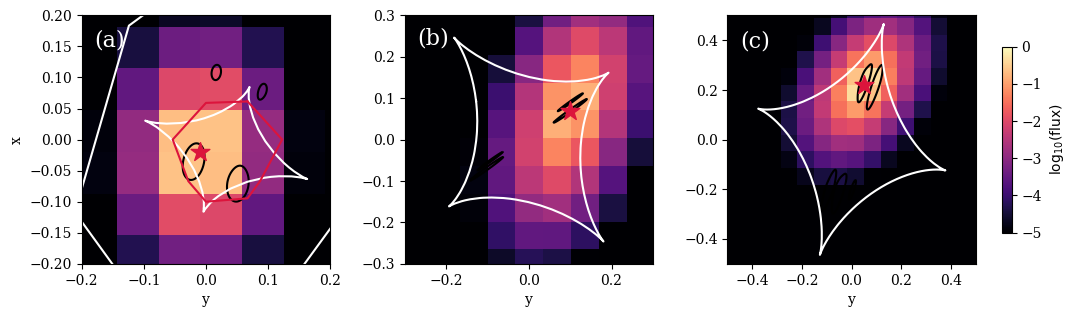

In [2]:
import lenstronomy as ls

from lenstronomy.LensModel.lens_model import LensModel
lens_model_list = ['EPL', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from seaborn import kdeplot
from pandas import DataFrame as df
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Data.pixel_grid import PixelGrid
import pickle 
from corner import corner 
import json 

plt.rcParams.update({'font.family': 'serif'})

print('-- SMALL SYSTEM --')

mcmc = '/home/lauraelina.uronen/GClocalization/small_system/Outdir_lens_reconstruction/position_mcmc.pkl'
with open(mcmc, 'rb') as f:
    mcmc_data = pickle.load(f)
kwargs = '/home/lauraelina.uronen/GClocalization/small_system/Outdir_lens_reconstruction/kwargs_result.json'
with open(kwargs) as f:
    kwargs_data = json.load(f)['kwargs_lens']
modelplot = '/home/lauraelina.uronen/GClocalization/small_system/Outdir_lens_reconstruction/modelplot.pkl'
with open(modelplot, 'rb') as f:
    model_data = pickle.load(f)
true = '/home/lauraelina.uronen/GClocalization/small_system/Outdir_lens_reconstruction/true_position.json'
with open(true) as f:
    true_data = json.load(f)

print('Fetched data for small system. Generating plot...')

kwargs_lens = kwargs_data
numPix = 100
deltaPix = 0.067 
shift = numPix * deltaPix / 2
ra_start, dec_start = 0 - shift, 0 - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
source = model_data.source(numPix=numPix, deltaPix=deltaPix)[0]
x, y = mcmc_data[:,0], mcmc_data[:,1]

fig, axes = plt.subplots(1, 3, figsize=(12,40))

ax = axes[0]
ax.imshow(np.log10(source), vmin=-5, vmax=0, cmap='magma', extent=(-shift-true_data['dec'], shift-true_data['dec'], -shift+true_data['ra'], shift+true_data['ra']))
lens_plot.caustics_plot(ax, pixel_grid=pixel_grid, lens_model=lensModel, kwargs_lens=kwargs_lens, color_caustic='white', color_crit='crimson')
dataframe = df({'x': x[-5000:], 'y': y[-5000:]})
kdeplot(x=-dataframe.y, y=dataframe.x, color='k', levels=[1-0.67], zorder=1, ax=ax)
ax.scatter(-true_data['dec'], true_data['ra'], marker='*', color='crimson', s=200, label='True position')
ax.text(-0.18, 0.15, '(a)', color='white', fontsize=16)
ax.set_xlim(-0.2,0.2)
ax.set_ylim(-0.2,0.2)

print('Plot generated for small system.')
print('-- AVERAGE SYSTEM --')

mcmc = '/home/lauraelina.uronen/GClocalization/average_system/Outdir_lens_reconstruction/position_mcmc.pkl'
with open(mcmc, 'rb') as f:
    mcmc_data = pickle.load(f)
kwargs= '/home/lauraelina.uronen/GClocalization/average_system/Outdir_lens_reconstruction/kwargs_result.json'
with open(kwargs) as f:
    kwargs_data = json.load(f)['kwargs_lens']
modelplot = '/home/lauraelina.uronen/GClocalization/average_system/Outdir_lens_reconstruction/modelplot.pkl'
with open(modelplot, 'rb') as f:
    model_data = pickle.load(f)
true = '/home/lauraelina.uronen/GClocalization/average_system/Outdir_lens_reconstruction/true_position.json'
with open(true) as f:
    true_data = json.load(f)

print('Fetched data for average system. Generating plot...')

kwargs_lens = kwargs_data
numPix = 50
deltaPix = 0.067 
shift = numPix * deltaPix / 2
ra_start, dec_start = 0 - shift, 0 - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
source = model_data.source(numPix=numPix, deltaPix=deltaPix)[0]
x, y = mcmc_data[:,0], mcmc_data[:,1]

ax = axes[1]
ax.imshow(np.log10(source), vmin=-5, vmax=0, cmap='magma', extent=(-shift-true_data['dec'], shift-true_data['dec'], -shift+true_data['ra'], shift+true_data['ra']))
kwargs_epl = {'theta_E': 1.0, 'center_x': 0, 'center_y': 0, 'e1': 0.1, 'e2': -0.2, 'gamma': 2}
kwargs_shear = {'gamma1': 0.1, 'gamma2': 0.0}
kwargs_lens = [kwargs_epl, kwargs_shear]
lensModel = LensModel(lens_model_list=lens_model_list)
lens_plot.caustics_plot(ax, pixel_grid=pixel_grid, lens_model=lensModel, kwargs_lens=kwargs_lens, color_caustic='white', color_crit='crimson')
dataframe = df({'x': x[-5000:], 'y': y[-5000:]})
kdeplot(x=-dataframe.y, y=dataframe.x, color='k', levels=[1-0.67], zorder=1, ax=ax)
ax.scatter(-true_data['dec'], true_data['ra'], marker='*', color='crimson', s=200, label='True position')
ax.text(-0.27, 0.23, '(b)', color='white', fontsize=16)
ax.set_ylabel('')
ax.set_xlim(-0.3,0.3)
ax.set_ylim(-0.3,0.3)

print('Plot generated for average system.')
print('-- BEST SYSTEM --')

mcmc = '/home/lauraelina.uronen/GClocalization/best_system/Outdir_lens_reconstruction/position_mcmc.pkl'
with open(mcmc, 'rb') as f:
    mcmc_data = pickle.load(f)
kwargs = '/home/lauraelina.uronen/GClocalization/best_system/Outdir_lens_reconstruction/kwargs_result.json'
with open(kwargs) as f:
    kwargs_data = json.load(f)['kwargs_lens']
modelplot = '/home/lauraelina.uronen/GClocalization/best_system/Outdir_lens_reconstruction/modelplot.pkl'
with open(modelplot, 'rb') as f:
    model_data = pickle.load(f)
true = '/home/lauraelina.uronen/GClocalization/best_system/Outdir_lens_reconstruction/true_position.json'
with open(true) as f:
    true_data = json.load(f)

print('Fetched data for best system. Generating plot...')

kwargs_lens = kwargs_data
numPix = 100
deltaPix = 0.067 
shift = numPix * deltaPix / 2
ra_start, dec_start = 0 - shift, 0 - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
source = model_data.source(numPix=numPix, deltaPix=deltaPix)[0]
x, y = mcmc_data[:,0], mcmc_data[:,1]

ax = axes[2]
ax.imshow(np.log10(source), vmin=-5, vmax=0, cmap='magma', extent=(-shift-true_data['dec'], shift-true_data['dec'], -shift+true_data['ra'], shift+true_data['ra']))
lens_plot.caustics_plot(ax, pixel_grid=pixel_grid, lens_model=lensModel, kwargs_lens=kwargs_lens, color_caustic='white', color_crit='crimson')
dataframe = df({'x': x[-5000:], 'y': y[-5000:]})
kdeplot(x=-dataframe.y, y=dataframe.x, color='k', levels=[1-0.67], zorder=1, ax=ax, label='67% credible region')
ax.scatter(-true_data['dec'], true_data['ra'], marker='*', color='crimson', s=200, label='True position')
ax.text(-0.45, 0.37, '(c)', color='white', fontsize=16)
ax.set_ylabel('')
ax.set_xlim(-0.5,0.5)
ax.set_ylim(-0.5,0.5)

print('Plot generated for best system.')

# make colorbar 
cbar = plt.colorbar(ax.images[0], ax=axes, orientation='vertical', fraction=0.01, pad=1)
cbar.set_label('$\log_{10}(\mathrm{flux})$')

plt.subplots_adjust(left=0.125, bottom=None, right=0.87, top=None, wspace=0.3, hspace=None)#
#plt.savefig('triple_system_plot.pdf', bbox_inches='tight', dpi=500)

-- UNC SYSTEM --
Fetched data for unc system. Generating plot...


/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Plot generated for unc system.
-- REL SYSTEM --
Fetched data for rel system. Generating plot...


/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Plot generated for rel system.


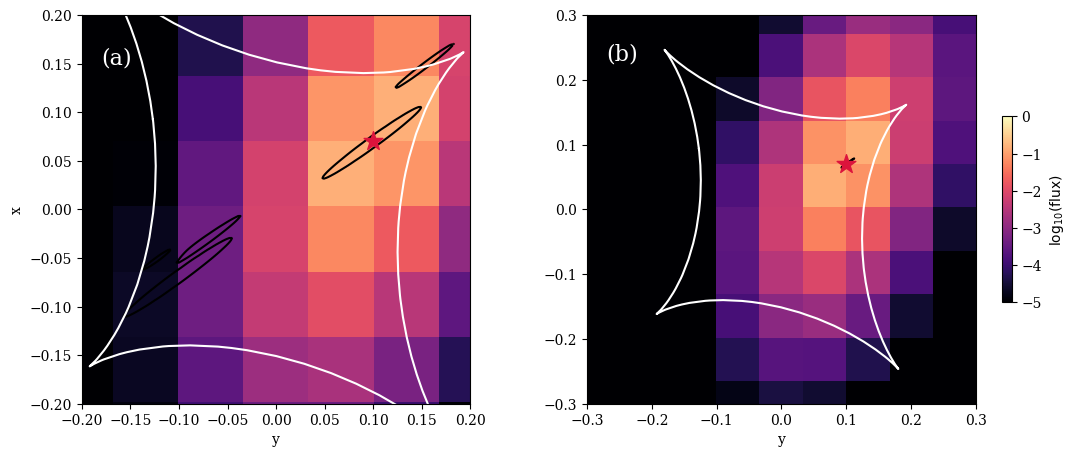

In [ ]:
import lenstronomy as ls

from lenstronomy.LensModel.lens_model import LensModel
lens_model_list = ['EPL', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from seaborn import kdeplot
from pandas import DataFrame as df
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Data.pixel_grid import PixelGrid
import pickle 
from corner import corner 
import json 

plt.rcParams.update({'font.family': 'serif'})

print('-- UNC SYSTEM --')

mcmc = '/home/lauraelina.uronen/GClocalization/average_system_unc/Outdir_lens_reconstruction/position_mcmc.pkl'
with open(mcmc, 'rb') as f:
    mcmc_data = pickle.load(f)
kwargs = '/home/lauraelina.uronen/GClocalization/average_system_unc/Outdir_lens_reconstruction/kwargs_result.json'
with open(kwargs) as f:
    kwargs_data = json.load(f)['kwargs_lens']
modelplot = '/home/lauraelina.uronen/GClocalization/average_system_unc/Outdir_lens_reconstruction/modelplot.pkl'
with open(modelplot, 'rb') as f:
    model_data = pickle.load(f)
true = '/home/lauraelina.uronen/GClocalization/average_system_unc/Outdir_lens_reconstruction/true_position.json'
with open(true) as f:
    true_data = json.load(f)

print('Fetched data for unc system. Generating plot...')

kwargs_lens = kwargs_data
numPix = 100
deltaPix = 0.067 
shift = numPix * deltaPix / 2
ra_start, dec_start = 0 - shift, 0 - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
source = model_data.source(numPix=numPix, deltaPix=deltaPix)[0]
x, y = mcmc_data[:,0], mcmc_data[:,1]

fig, axes = plt.subplots(1, 2, figsize=(12,20))

ax = axes[0]
ax.imshow(np.log10(source), vmin=-5, vmax=0, cmap='magma', extent=(-shift-true_data['dec'], shift-true_data['dec'], -shift+true_data['ra'], shift+true_data['ra']))
lens_plot.caustics_plot(ax, pixel_grid=pixel_grid, lens_model=lensModel, kwargs_lens=kwargs_lens, color_caustic='white', color_crit='crimson')
dataframe = df({'x': x[-5000:], 'y': y[-5000:]})
kdeplot(x=-dataframe.y, y=dataframe.x, color='k', levels=[1-0.67], zorder=1, ax=ax)
ax.scatter(-true_data['dec'], true_data['ra'], marker='*', color='crimson', s=200, label='True position')
ax.text(-0.18, 0.15, '(a)', color='white', fontsize=16)
ax.set_xlim(-0.2,0.2)
ax.set_ylim(-0.2,0.2)

print('Plot generated for unc system.')
print('-- REL SYSTEM --')

mcmc = '/home/lauraelina.uronen/GClocalization/average_system_rrel/Outdir_lens_reconstruction/position_mcmc.pkl'
with open(mcmc, 'rb') as f:
    mcmc_data = pickle.load(f)
kwargs = '/home/lauraelina.uronen/GClocalization/average_system_rrel/Outdir_lens_reconstruction/kwargs_result.json'
with open(kwargs) as f:
    kwargs_data = json.load(f)['kwargs_lens']
modelplot = '/home/lauraelina.uronen/GClocalization/average_system_rrel/Outdir_lens_reconstruction/modelplot.pkl'
with open(modelplot, 'rb') as f:
    model_data = pickle.load(f)
true = '/home/lauraelina.uronen/GClocalization/average_system_rrel/Outdir_lens_reconstruction/true_position.json'
with open(true) as f:
    true_data = json.load(f)

print('Fetched data for rel system. Generating plot...')

kwargs_lens = kwargs_data
numPix = 50
deltaPix = 0.067 
shift = numPix * deltaPix / 2
ra_start, dec_start = 0 - shift, 0 - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
source = model_data.source(numPix=numPix, deltaPix=deltaPix)[0]
x, y = mcmc_data[:,0], mcmc_data[:,1]

xrel = 0.06509895780603903
yrel = -0.09358101002136096

ax = axes[1]
ax.imshow(np.log10(source), vmin=-5, vmax=0, cmap='magma', extent=(-shift-true_data['dec'], shift-true_data['dec'], -shift+true_data['ra'], shift+true_data['ra']))
kwargs_epl = {'theta_E': 1.0, 'center_x': 0, 'center_y': 0, 'e1': 0.1, 'e2': -0.2, 'gamma': 2}
kwargs_shear = {'gamma1': 0.1, 'gamma2': 0.0}
kwargs_lens = [kwargs_epl, kwargs_shear]
lensModel = LensModel(lens_model_list=lens_model_list)
lens_plot.caustics_plot(ax, pixel_grid=pixel_grid, lens_model=lensModel, kwargs_lens=kwargs_lens, color_caustic='white', color_crit='crimson')
dataframe = df({'x': x[-5000:] + xrel, 'y': y[-5000:] + yrel})
kdeplot(x=-dataframe.y, y=dataframe.x, color='k', levels=[1-0.67], zorder=1, ax=ax)
ax.scatter(-true_data['dec'], true_data['ra'], marker='*', color='crimson', s=200, label='True position')
ax.text(-0.27, 0.23, '(b)', color='white', fontsize=16)
ax.set_ylabel('')
ax.set_xlim(-0.3,0.3)
ax.set_ylim(-0.3,0.3)

print('Plot generated for rel system.')

# make colorbar 
cbar = plt.colorbar(ax.images[0], ax=axes, orientation='vertical', fraction=0.01, pad=1)
cbar.set_label('$\log_{10}(\mathrm{flux})$')

plt.subplots_adjust(left=0.125, bottom=None, right=0.87, top=None, wspace=0.3, hspace=None)
plt.savefig('test_system_plot.pdf', bbox_inches='tight', dpi=500)